<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Walmart_Sales_Forecasting/blob/main/model_experiment_SARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup & MLflow

In [12]:
!pip install -q mlflow dagshub
!pip install -q --upgrade statsmodels

import os, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from google.colab import userdata
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

os.environ['MLFLOW_TRACKING_USERNAME'] = 'adzid23'
os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('DAGSHUB_TOKEN')

mlflow.set_tracking_uri('https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow')
mlflow.set_experiment('SARIMA_Training')
print('MLflow connected:', mlflow.get_tracking_uri())

MLflow connected: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow


## 2. Data & Split

In [13]:
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_KEY')
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting -q

os.makedirs('walmart_data', exist_ok=True)
with zipfile.ZipFile('walmart-recruiting-store-sales-forecasting.zip') as z:
    z.extractall('walmart_data')
for f in os.listdir('walmart_data'):
    if f.endswith('.zip'):
        with zipfile.ZipFile(f'walmart_data/{f}') as z:
            z.extractall('walmart_data')

train = pd.read_csv('walmart_data/train.csv', parse_dates=['Date'])
test = pd.read_csv('walmart_data/test.csv',  parse_dates=['Date'])
print(train.shape, test.shape)
print('Train:', train['Date'].min().date(), '→', train['Date'].max().date())
print('Test :', test['Date'].min().date(),  '→', test['Date'].max().date())

(421570, 5) (115064, 4)
Train: 2010-02-05 → 2012-10-26
Test : 2012-11-02 → 2013-07-26


In [14]:
# Each (Store, Dept) becomes one weekly time series with a complete weekly index.
# Missing weeks are filled with 0 — in this dataset a missing week almost always
# means the department recorded no sales, and ARIMA requires evenly spaced data.

full_index = pd.date_range(train['Date'].min(), train['Date'].max(), freq='W-FRI')

def make_series(g):
    s = g.set_index('Date')['Weekly_Sales'].reindex(full_index).fillna(0.0)
    return s

series = {key: make_series(g) for key, g in train.groupby(['Store', 'Dept'])}

lengths = train.groupby(['Store', 'Dept']).size()
print('Series total          :', len(series))
print('Full-length (143 wks) :', (lengths == 143).sum())
print('Short (<104 weeks)    :', (lengths < 104).sum())
print('Very short (<52 weeks):', (lengths < 52).sum())

Series total          : 3331
Full-length (143 wks) : 2660
Short (<104 weeks)    : 463
Very short (<52 weeks): 340


In [15]:
VAL_WEEKS = 13
val_start = full_index[-VAL_WEEKS]

holiday_map = train.drop_duplicates('Date').set_index('Date')['IsHoliday']
holiday_map = holiday_map.reindex(full_index).fillna(False)

def wmae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday, 5.0, 1.0)
    return np.sum(w * np.abs(y_true - y_pred)) / np.sum(w)

train_end_idx = len(full_index) - VAL_WEEKS
print('Fit on   :', full_index[0].date(), '→', full_index[train_end_idx-1].date())
print('Validate :', val_start.date(), '→', full_index[-1].date())
print('Holidays in validation window:', holiday_map[val_start:].sum())

Fit on   : 2010-02-05 → 2012-07-27
Validate : 2012-08-03 → 2012-10-26
Holidays in validation window: 1


In [16]:
lengths = train.groupby(['Store', 'Dept']).size()
mean_sales = train.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()
full_keys = [k for k in series if lengths.get(k, 0) == 143]
full_set  = set(full_keys)

top300 = [k for k in mean_sales.sort_values(ascending=False).index if k in full_set][:300]
pool2  = [k for k in full_keys if k not in set(top300)]
rng7   = np.random.default_rng(7)                      # SAME seed as ARIMA → same 600 series
rand300 = [pool2[i] for i in rng7.choice(len(pool2), size=300, replace=False)]
VAL_KEYS = top300 + rand300

with mlflow.start_run(run_name='SARIMA_Data_Preparation'):
    mlflow.set_tags({'stage': 'preprocessing', 'model_family': 'SARIMA', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Identical construction to ARIMA_Data_Preparation (same seed → same 600 '
        'validation series) so all WMAE numbers are directly comparable across experiments. '
        'Carried over from ARIMA: log1p transform, 13-week split. '
        'Reference bar: snaive 3611.4, ARIMA log1p 3637.7.')
    mlflow.log_params({'n_series': len(series), 'val_weeks': VAL_WEEKS,
                       'seasonal_period_m': 52, 'transform': 'log1p',
                       'val_sampling': '300 top + 300 random, seed 7 (same as ARIMA)'})

🏃 View run SARIMA_Data_Preparation at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1/runs/4ea5c4ec9b714f268ee5ba89c15decf5
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1


In [17]:
w_val = np.where(holiday_map[val_start:].values, 5.0, 1.0)
print(w_val)

[1. 1. 1. 1. 1. 5. 1. 1. 1. 1. 1. 1. 1.]


## 3. Seasonal diagnostics

In [7]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def adf_pvalue(s):
    try:    return adfuller(s.dropna(), autolag='AIC')[1]
    except Exception: return np.nan

rng = np.random.default_rng(42)                        # same seed as ARIMA ADF sample
sample_keys = [full_keys[i] for i in rng.choice(len(full_keys), size=100, replace=False)]

variants = {
    'level':  lambda s: s,
    'd1':     lambda s: s.diff(),
    'D52':    lambda s: s.diff(52),
    'd1_D52': lambda s: s.diff(52).diff(),
}
pct = {}
for name, f in variants.items():
    p = np.array([adf_pvalue(f(np.log1p(series[k][:val_start][:-1]))) for k in sample_keys])
    pct[name] = np.nanmean(p < 0.05) * 100
    print(f'{name:7s}: {pct[name]:.0f}% stationary')

level  : 74% stationary
d1     : 100% stationary
D52    : 72% stationary
d1_D52 : 100% stationary


🏃 View run SARIMA_Seasonal_Diagnostics at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1/runs/dab2befab49b4246bd6b62565f70cd6e
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1


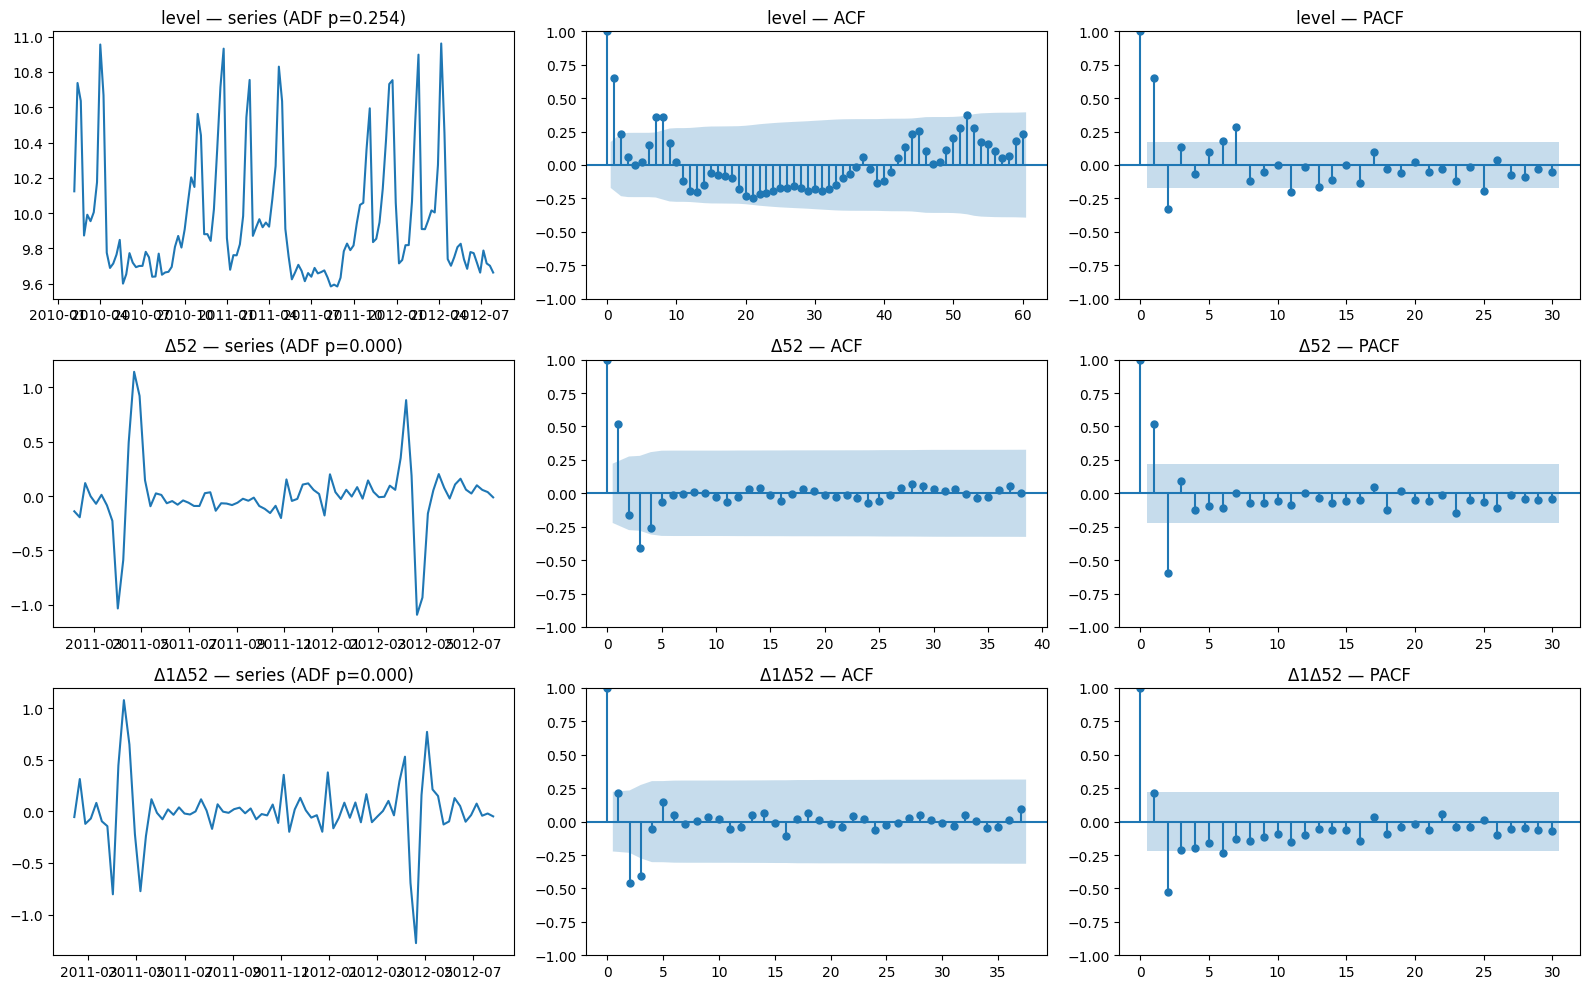

In [8]:
key = (1, 1)
s = np.log1p(series[key][:val_start][:-1])
tf = {'level': s, 'Δ52': s.diff(52).dropna(), 'Δ1Δ52': s.diff(52).diff().dropna()}

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for i, (name, x) in enumerate(tf.items()):
    axes[i, 0].plot(x); axes[i, 0].set_title(f'{name} — series (ADF p={adf_pvalue(x):.3f})')
    plot_acf(x,  lags=min(60, len(x)//2 - 1), ax=axes[i, 1], title=f'{name} — ACF')
    plot_pacf(x, lags=min(30, len(x)//2 - 1), ax=axes[i, 2], method='ywm', title=f'{name} — PACF')
plt.tight_layout()

with mlflow.start_run(run_name='SARIMA_Seasonal_Diagnostics'):
    mlflow.set_tags({'stage': 'diagnostics', 'model_family': 'SARIMA', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        f'ADF on 100 series (log1p space): level {pct["level"]:.0f}%, d1 {pct["d1"]:.0f}%, '
        f'D52 {pct["D52"]:.0f}%, d1+D52 {pct["d1_D52"]:.0f}%. Seasonal difference costs 52 obs '
        f'(130 → 78 effective). Note: Δ52 series = seasonal-naive forecast errors.')
    mlflow.log_metrics({f'pct_stationary_{k}': v for k, v in pct.items()})
    mlflow.log_figure(fig, 'seasonal_diagnostics_store1_dept1.png')
plt.show()

## 4. Fit Cost

In [9]:
import time
from statsmodels.tsa.statespace.sarimax import SARIMAX

bench_key = (1, 1)
tr = np.log1p(series[bench_key][:val_start][:-1])

bench_orders = [
    ((0,1,1), (0,1,1,52)),
    ((1,1,1), (0,1,1,52)),
    ((1,1,1), (1,1,1,52)),
    ((2,1,2), (0,1,1,52)),
]
timings = {}
for order, sorder in bench_orders:
    t0 = time.time()
    SARIMAX(tr, order=order, seasonal_order=sorder,
            enforce_stationarity=False, enforce_invertibility=False
           ).fit(disp=0, maxiter=200)
    dt = time.time() - t0
    timings[f'{order}x{sorder}'] = dt
    print(f'{order} x {sorder}: {dt:.1f}s  → 600 series ≈ {dt*600/60:.0f} min, 3331 ≈ {dt*3331/3600:.1f} h')

with mlflow.start_run(run_name='SARIMA_Fit_Cost_Benchmark'):
    mlflow.set_tags({'stage': 'benchmark', 'model_family': 'SARIMA', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Single-series fit timings at m=52 with projections to 600/3331 series. '
        'Motivates: (a) small grid on few series, (b) sampled validation, '
        '(c) Fourier-terms alternative for full-scale runs. Compare: plain ARIMA ~0.2-1.5s/fit.')
    mlflow.log_metrics({f'fit_seconds_{i}': v for i, v in enumerate(timings.values())})
    mlflow.log_params({'orders_timed': str(bench_orders), 'series': str(bench_key)})

(0, 1, 1) x (0, 1, 1, 52): 11.1s  → 600 series ≈ 111 min, 3331 ≈ 10.3 h
(1, 1, 1) x (0, 1, 1, 52): 11.4s  → 600 series ≈ 114 min, 3331 ≈ 10.5 h
(1, 1, 1) x (1, 1, 1, 52): 8.1s  → 600 series ≈ 81 min, 3331 ≈ 7.5 h
(2, 1, 2) x (0, 1, 1, 52): 14.9s  → 600 series ≈ 149 min, 3331 ≈ 13.7 h
🏃 View run SARIMA_Fit_Cost_Benchmark at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1/runs/897d407721054e58aedd7bf1ec0f48c1
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1


## 5. Seasonal order selection

In [18]:
grid10 = top300[:5] + rand300[:5]     # 5 giants + 5 random, deterministic

sarima_candidates = [
    ((0,1,1), (0,1,1,52)),   # airline model — the canonical SARIMA
    ((1,1,1), (0,1,1,52)),
    ((2,1,2), (0,1,1,52)),   # ARIMA winner + seasonal MA
    ((1,1,1), (1,1,0,52)),
    ((1,1,1), (1,1,1,52)),
    ((0,1,1), (0,1,0,52)),   # pure double differencing + MA(1): cheapest
    ((1,1,2), (0,1,1,52)),
]

def eval_sarima(order, sorder):
    errs, wsum, aics, n_ok = 0.0, 0.0, [], 0
    for k in grid10:
        s = series[k]
        tr = np.log1p(s[:val_start][:-1])
        try:
            m = SARIMAX(tr, order=order, seasonal_order=sorder,
                        enforce_stationarity=False, enforce_invertibility=False
                       ).fit(disp=0, maxiter=200)
            fc = np.maximum(np.expm1(np.asarray(m.forecast(VAL_WEEKS))), 0.0)
            if not np.all(np.isfinite(fc)): raise ValueError
            errs += np.sum(w_val * np.abs(s[val_start:].values - fc))
            wsum += w_val.sum(); aics.append(m.aic); n_ok += 1
        except Exception:
            continue
    return errs / wsum if wsum else np.nan, np.mean(aics) if aics else np.nan, n_ok

rows = []
for order, sorder in sarima_candidates:
    vw, aic, n_ok = eval_sarima(order, sorder)
    rows.append({'order': str(order), 'seasonal': str(sorder),
                 'val_WMAE': round(vw, 1), 'mean_AIC': round(aic, 1), 'n_ok': n_ok})
    print(rows[-1])

sgrid_df = pd.DataFrame(rows).sort_values('val_WMAE')
display(sgrid_df)

{'order': '(0, 1, 1)', 'seasonal': '(0, 1, 1, 52)', 'val_WMAE': np.float64(4409.7), 'mean_AIC': np.float64(-34.8), 'n_ok': 10}
{'order': '(1, 1, 1)', 'seasonal': '(0, 1, 1, 52)', 'val_WMAE': np.float64(4434.5), 'mean_AIC': np.float64(-35.0), 'n_ok': 10}
{'order': '(2, 1, 2)', 'seasonal': '(0, 1, 1, 52)', 'val_WMAE': np.float64(4423.6), 'mean_AIC': np.float64(-33.6), 'n_ok': 10}
{'order': '(1, 1, 1)', 'seasonal': '(1, 1, 0, 52)', 'val_WMAE': np.float64(4447.3), 'mean_AIC': np.float64(-35.7), 'n_ok': 10}
{'order': '(1, 1, 1)', 'seasonal': '(1, 1, 1, 52)', 'val_WMAE': np.float64(4507.3), 'mean_AIC': np.float64(-33.2), 'n_ok': 10}
{'order': '(0, 1, 1)', 'seasonal': '(0, 1, 0, 52)', 'val_WMAE': np.float64(4643.5), 'mean_AIC': np.float64(-96.7), 'n_ok': 10}
{'order': '(1, 1, 2)', 'seasonal': '(0, 1, 1, 52)', 'val_WMAE': np.float64(4429.0), 'mean_AIC': np.float64(-34.1), 'n_ok': 10}


,order,seasonal,val_WMAE,mean_AIC,n_ok
0,"(0, 1, 1)","(0, 1, 1, 52)",4409.7,-34.8,10
2,"(2, 1, 2)","(0, 1, 1, 52)",4423.6,-33.6,10
6,"(1, 1, 2)","(0, 1, 1, 52)",4429.0,-34.1,10
1,"(1, 1, 1)","(0, 1, 1, 52)",4434.5,-35.0,10
3,"(1, 1, 1)","(1, 1, 0, 52)",4447.3,-35.7,10
4,"(1, 1, 1)","(1, 1, 1, 52)",4507.3,-33.2,10
5,"(0, 1, 1)","(0, 1, 0, 52)",4643.5,-96.7,10


In [21]:
sgrid_df.to_csv('sarima_order_grid.csv', index=False)
best = sgrid_df.iloc[0]

with mlflow.start_run(run_name='SARIMA_Order_Selection'):
    mlflow.set_tags({'stage': 'order_selection', 'model_family': 'SARIMA',
                     'author': 'adzid23', 'best_config': best['order'] + 'x' + best['seasonal']})
    mlflow.set_tag('mlflow.note.content',
        'Grid of 7 (p,d,q)(P,D,Q,52) candidates on 10 series (5 top + 5 random), '
        'log1p space, d=1 D=1 fixed by diagnostics (D52 alone leaves drift: 72% vs 100%). '
        'Candidates kept small: 78 effective obs / 2.5 seasonal cycles cannot support P,Q>1.')
    mlflow.log_params({'n_candidates': len(sarima_candidates), 'grid_series': 10,
                       'd': 1, 'D': 1, 'm': 52})
    mlflow.log_metric('best_val_wmae_grid10', best['val_WMAE'])
    mlflow.log_artifact('sarima_order_grid.csv')

🏃 View run SARIMA_Order_Selection at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1/runs/36b374035f4748e1bc86e92ce70a10f8
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1


In [22]:
BEST_SARIMA = ((0, 1, 1), (0, 1, 1, 52))

## 6. Validation on 200 series

In [23]:
VAL200 = top300[:100] + rand300[:100]

# Baselines on this exact subset
num = {'naive': 0.0, 'snaive': 0.0}; den = 0.0
for k in VAL200:
    s = series[k]; va = s[val_start:].values
    num['naive']  += np.sum(w_val * np.abs(va - np.repeat(s[:val_start][:-1].iloc[-1], VAL_WEEKS)))
    num['snaive'] += np.sum(w_val * np.abs(va - s.shift(52)[val_start:].values))
    den += w_val.sum()
bl200 = {k_: v / den for k_, v in num.items()}
print(f"naive {bl200['naive']:.1f} | snaive {bl200['snaive']:.1f}")

# SARIMA
def fit_forecast_sarima(key):
    tr_raw = series[key][:val_start][:-1]
    try:
        m = SARIMAX(np.log1p(tr_raw), order=BEST_SARIMA[0], seasonal_order=BEST_SARIMA[1],
                    enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=0, maxiter=200)
        fc = np.expm1(np.asarray(m.forecast(VAL_WEEKS)))
        if not np.all(np.isfinite(fc)): raise ValueError
        return np.maximum(fc, 0.0), True
    except Exception:
        return np.repeat(max(tr_raw.iloc[-1], 0.0), VAL_WEEKS), False

num_s = den_s = 0.0; n_fb = 0
for k in tqdm(VAL200):
    fc, ok = fit_forecast_sarima(k)
    va = series[k][val_start:].values
    num_s += np.sum(w_val * np.abs(va - fc)); den_s += w_val.sum(); n_fb += (not ok)

sarima_wmae = num_s / den_s
print(f'SARIMA{BEST_SARIMA} WMAE: {sarima_wmae:.1f}')
print(f'vs naive {bl200["naive"]:.1f} | snaive {bl200["snaive"]:.1f} | fallbacks {n_fb}/200')

naive 5820.0 | snaive 4604.0


  0%|          | 0/200 [00:00<?, ?it/s]

SARIMA((0, 1, 1), (0, 1, 1, 52)) WMAE: 3291.7
vs naive 5820.0 | snaive 4604.0 | fallbacks 0/200


In [24]:
with mlflow.start_run(run_name='SARIMA_Validation'):
    mlflow.set_tags({'stage': 'validation', 'model_family': 'SARIMA', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        f'SARIMA(0,1,1)(0,1,1,52) on log1p, 200 series (100 top + 100 random), '
        f'13-week holdout. Baselines recomputed on same subset. Fit cost forced '
        f'the 200-series budget (~11s/fit at m=52).')
    mlflow.log_params({'order': str(BEST_SARIMA[0]), 'seasonal_order': str(BEST_SARIMA[1]),
                       'transform': 'log1p', 'n_series': 200})
    mlflow.log_metrics({'val_wmae': sarima_wmae,
                        'val_wmae_naive': bl200['naive'], 'val_wmae_snaive': bl200['snaive'],
                        'improvement_vs_snaive_pct': 100*(1 - sarima_wmae/bl200['snaive']),
                        'n_fallback': n_fb})

🏃 View run SARIMA_Validation at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1/runs/cd05f537bff74421812a27519c76dfb4
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1


## 7. Fourier Terms

In [25]:
def fourier_matrix(n, K, m=52, start=0):
    t = np.arange(start, start + n)
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin{k}'] = np.sin(2 * np.pi * k * t / m)
        cols[f'cos{k}'] = np.cos(2 * np.pi * k * t / m)
    return pd.DataFrame(cols)

def fit_forecast_fourier(key, K, order=(1, 1, 1)):
    tr_raw = series[key][:val_start][:-1]
    n_tr = len(tr_raw)
    X_tr = fourier_matrix(n_tr, K)
    X_fc = fourier_matrix(VAL_WEEKS, K, start=n_tr)
    try:
        m_ = SARIMAX(np.log1p(tr_raw).values, exog=X_tr, order=order,
                     enforce_stationarity=False, enforce_invertibility=False
                    ).fit(disp=0, maxiter=200)
        fc = np.expm1(np.asarray(m_.forecast(VAL_WEEKS, exog=X_fc)))
        if not np.all(np.isfinite(fc)): raise ValueError
        return np.maximum(fc, 0.0), True
    except Exception:
        return np.repeat(max(tr_raw.iloc[-1], 0.0), VAL_WEEKS), False

for K in [3, 6, 10]:
    errs = wsum = 0.0
    for k in grid10:
        fc, _ = fit_forecast_fourier(k, K)
        va = series[k][val_start:].values
        errs += np.sum(w_val * np.abs(va - fc)); wsum += w_val.sum()
    print(f'K={K:2d}: grid10 WMAE {errs/wsum:.1f}')

K= 3: grid10 WMAE 6181.9
K= 6: grid10 WMAE 5495.4
K=10: grid10 WMAE 6112.6


In [26]:
num_f = den_f = 0.0; n_fb_f = 0
for k in tqdm(VAL200):
    fc, ok = fit_forecast_fourier(k, K=6)
    va = series[k][val_start:].values
    num_f += np.sum(w_val * np.abs(va - fc)); den_f += w_val.sum(); n_fb_f += (not ok)

fourier_wmae = num_f / den_f
print(f'Fourier K=6 WMAE: {fourier_wmae:.1f}  (SARIMA 3291.7 | snaive 4604.0)')

with mlflow.start_run(run_name='SARIMA_Fourier_Validation'):
    mlflow.set_tags({'stage': 'validation', 'model_family': 'SARIMA',
                     'author': 'adzid23', 'method': 'dynamic harmonic regression'})
    mlflow.set_tag('mlflow.note.content',
        'ARIMA(1,1,1) + Fourier(K=6, m=52) exog terms, log1p, same 200 series. '
        'Negative result: Fourier assumes smooth seasonality; Walmart has 1-2 week '
        'holiday impulses — high K needed to trace spikes overfits 130 obs. '
        'Grid: K=3→6182, K=6→5495, K=10→6113 (grid10). Seasonal differencing wins.')
    mlflow.log_params({'K': 6, 'order': '(1,1,1)', 'n_series': 200})
    mlflow.log_metrics({'val_wmae': fourier_wmae, 'val_wmae_sarima': 3291.7,
                        'val_wmae_snaive': 4604.0, 'n_fallback': n_fb_f})

  0%|          | 0/200 [00:00<?, ?it/s]

Fourier K=6 WMAE: 3798.2  (SARIMA 3291.7 | snaive 4604.0)
🏃 View run SARIMA_Fourier_Validation at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1/runs/3447de53686d4ecdbd3a0fab6107b62e
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1


## 8. Pipeline

In [27]:
import mlflow.pyfunc

class SARIMALogPipeline(mlflow.pyfunc.PythonModel):
    ORDER = (0, 1, 1)
    SORDER = (0, 1, 1, 52)
    FALLBACK_ORDER = (2, 1, 2)      # plain-ARIMA winner, for short series
    MIN_OBS = 105                   # ~2 seasonal cycles needed for D=1

    def load_context(self, context):
        import pandas as pd
        tr = pd.read_csv(context.artifacts['train_csv'], parse_dates=['Date'])
        self.full_index = pd.date_range(tr['Date'].min(), tr['Date'].max(), freq='W-FRI')
        self.series = {k: g.set_index('Date')['Weekly_Sales']
                          .reindex(self.full_index).fillna(0.0)
                       for k, g in tr.groupby(['Store', 'Dept'])}
        self.dept_mean = tr.groupby('Dept')['Weekly_Sales'].mean().to_dict()
        self.n_obs = tr.groupby(['Store', 'Dept']).size().to_dict()

    def _forecast_series(self, key, horizon):
        import numpy as np
        from statsmodels.tsa.statespace.sarimax import SARIMAX
        s = self.series[key]
        n = self.n_obs.get(key, 0)
        if n < 20:
            return np.repeat(max(s.iloc[-1], 0.0), horizon)
        seasonal = n >= self.MIN_OBS
        try:
            m = SARIMAX(np.log1p(s),
                        order=self.ORDER if seasonal else self.FALLBACK_ORDER,
                        seasonal_order=self.SORDER if seasonal else (0, 0, 0, 0),
                        enforce_stationarity=False, enforce_invertibility=False
                       ).fit(disp=0, maxiter=200)
            fc = np.expm1(np.asarray(m.forecast(horizon)))
            if not np.all(np.isfinite(fc)): raise ValueError
            return np.maximum(fc, 0.0)
        except Exception:
            return np.repeat(max(s.iloc[-1], 0.0), horizon)

    def predict(self, context, model_input):
        import numpy as np, pandas as pd
        df = model_input.copy()
        df['Date'] = pd.to_datetime(df['Date'])
        horizon = int(np.ceil((df['Date'].max() - self.full_index[-1]).days / 7))
        future_index = pd.date_range(self.full_index[-1] + pd.Timedelta(weeks=1),
                                     periods=horizon, freq='W-FRI')
        step_of = {d: i for i, d in enumerate(future_index)}
        preds = np.zeros(len(df))
        for key, g in df.groupby(['Store', 'Dept']):
            if key in self.series:
                fc = self._forecast_series(key, horizon)
                preds[g.index] = [fc[step_of[d]] if d in step_of else 0.0 for d in g['Date']]
            else:
                preds[g.index] = self.dept_mean.get(key[1], 0.0)
        return preds

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [28]:
sample = pd.concat([
    test[(test.Store == 1) & (test.Dept == 1)].head(5),
    test[(test.Store == 14) & (test.Dept == 92)].head(5),
]).reset_index(drop=True)

class _Ctx: artifacts = {'train_csv': 'walmart_data/train.csv'}
pipe = SARIMALogPipeline(); pipe.load_context(_Ctx())
print(pipe.predict(_Ctx(), sample[['Store', 'Dept', 'Date']]))

[ 37162.69656698  19222.18811884  19408.71761258  19949.87060351
  23999.48670469 176784.83223042 173187.53979459 165943.94664975
 187103.58894335 148909.12842079]


In [29]:
from mlflow.models.signature import infer_signature

with mlflow.start_run(run_name='SARIMA_Final_Pipeline'):
    mlflow.set_tags({'stage': 'pipeline', 'model_family': 'SARIMA', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'SARIMA(0,1,1)(0,1,1,52) on log1p, per-series fit at predict time. '
        'val WMAE 3291.7 vs snaive 4604.0 (−28.5%) on 200 series. Fallback chain: '
        '<105 obs → ARIMA(2,1,2); <20 obs → naive; unseen pair → dept mean. '
        'Warning: full test.csv pass ≈ 3.5-4h (3.8s × 3331 series).')
    mlflow.log_params({'order': '(0,1,1)', 'seasonal_order': '(0,1,1,52)',
                       'transform': 'log1p', 'min_obs_seasonal': 105})
    mlflow.log_metrics({'val_wmae': 3291.7, 'val_wmae_naive': 5820.0,
                        'val_wmae_snaive': 4604.0, 'val_wmae_fourier_k6': 3798.2})
    sig = infer_signature(sample[['Store', 'Dept', 'Date']],
                          pipe.predict(_Ctx(), sample[['Store', 'Dept', 'Date']]))
    mlflow.pyfunc.log_model(artifact_path='sarima_log_pipeline',
                            python_model=SARIMALogPipeline(),
                            artifacts={'train_csv': 'walmart_data/train.csv'},
                            signature=sig,
                            pip_requirements=['statsmodels', 'pandas', 'numpy'])

2026/07/11 20:41:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 20:41:11 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run SARIMA_Final_Pipeline at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1/runs/6ce371e54d604996b9860cf442365636
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/1
